**Coursebook: Classification in Machine Learning**

- Part of Comprehensive Data Science and Machine Learning Program for PT Freeport Indonesia
- Course Length: 9 Hours
- Last Updated: September 2025

---

- Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

# Background
 
The coursebook is part of the **Comprehensive Data Science and Machine Learning Program** prepared by Algoritma. The coursebook is intended for a restricted audience only, i.e. the individuals and organizations having received this coursebook directly from the training organization. It may not be reproduced, distributed, translated or adapted in any form outside these individuals and organizations without permission.

Algoritma is a data science education center based in Jakarta. We organize workshops and training programs to help working professionals and students gain mastery in various data science sub-fields: data visualization, machine learning, data modeling, statistical inference etc.

## Training Objectives

This coursebook is intended for participants who have completed the preceding courses. 

The coursebook focuses on:

- Classification Concept

- Data Preparation & Exploratory Data

- Data Pre-processing

    - Target & predictors splitting
    - Dummy Variables for Categorical Predictor
    - Cross Validation

- **Decision Tree**

    - Splitting Criterion (CART Algorithm)
    - Interpretation
    - Application of Decision Tree (Machine Learning Workflow)

- **Modeling Improvement Technique**
  
    - Evaluation Metrics
    - Sampling
    - Regularization
    - k-fold Cross Validation
    - Hyperparameter Search

- **Ensemble-based Methods**
  
    - Random Forest
    
- Performance Evaluation and Model Selection

    - Confusion matrix
    - Confusion Matrix Consideration  

- Model Implementation

    - Model prediction

The final part of this course is a Graded Assignment, where you are expected to apply all that you've learned on a new dataset, and attempt the given questions.

# Classification in Machine Learning

Classification is one of the main tasks in machine learning that deals with grouping objects into labelled classes or categories. The goal is to identify or predict the class label of data based on its information or features. In the context of classification, the data used to train the model is known as training data, and each training data has a known class label.

In general, classification can be divided into two main categories: binary classification and multiclass classification.

1. **Binary Classification:**
   - In binary classification, the model predicts whether an instance/data falls into one of two possible classes. For example, email spam detection (spam or non-spam), identification of whether a patient has a certain disease (positive or negative), etc.

2. **Multiclass Classification:**
   - Multiclass classification involves more than two classes. The model is designed to predict the class of an instance/data that may belong to one of three or more classes. Examples include handwritten digit classification (0-9), flower type classification (e.g., iris with multiple species), etc.

Here are some of the main components in the concept of classification in machine learning:

1. **Training Data:** Data that is used to train the classification model. Each training data instance has known features and class labels. For example, in spam or non-spam classification, the features can be the words in the email, and the class label is “spam” or “non-spam”.

2. **Features:** Information used by the model to make predictions. These features can be attributes or characteristics of the data used. For example, in image classification, features may include pixel color intensity, texture, and object shape.

3. **Classification Models:** Algorithms or mathematical structures used to learn patterns or relationships between features and class labels from training data. Examples of classification models include logistic regression, k-Nearest Neighbors (k-NN), etc.

4. **Training:** The process where the classification model “learns” from the training data. The model updates its parameters or weights based on patterns found in the training data to be able to make accurate predictions on previously unseen data.

5. **Model Validation and Evaluation:** After training the model, an evaluation is required to measure how well the model can generalize patterns to new data. This can involve dividing the training data into training and validation subsets, or using cross-validation techniques. Common evaluation metrics include accuracy, precision, and recall.

6. **Prediction:** Once the model has been trained and evaluated, it can be used to make predictions on new data not seen before. The model takes features from the new data and outputs a prediction of the corresponding class label.

# Decision Tree Concept

Decision trees and tree-based models are powerful, incredibly versatile and represent one of the most popular choice for machine learning tasks. Their output are also a powerful form of representing rules, which has the benefit of being interpretable and adaptable to almost any scenario.  

Decision trees, random forests and other tree-based models are so widely used it's behind many of the technology we use today. It's behind the face recognition feature in iOS devices, and is what Microsoft and Xbox engineers chose to implement when it needs its Kinect to "quickly and accurately predict 3D positions of body joints from a single depth image using no temporal information." Reference: [Real-Time Human Pose Recognition in Parts from Single Depth Images](http://research.microsoft.com/pubs/145347/BodyPartRecognition.pdf)

The whitepaper authors and researchers (linked above) observed that by using decision trees, they were able to perform their tasks in order of magnitude faster; As they compare it to a nearest neighbor + chamfer matching approach they still achieve more accurate results while being 100x faster. 

Decision trees are the representation of "rule", that we can easily understand in real world. In sort, it's a bunch of `if-then-else` statement. If you ever create a rule in deciding what phone to buy, and then ended up in splitting phone type based on the need, you already created a decision tree. In the example below, you'll see the common meme about choosing an OS, described in decision tree.

![](assets/os_meme.png)

In most cases, decision trees and its derivatives considered to be the one of the most powerful yet light models in classification problems.

## Iris Dataset

For an illustration, imagine we want to build a simple model that classify different specifies of iris flower based on the flower's sepal and petal measurements:

![](assets/iris.png)

In [19]:
from sklearn.datasets import load_iris
X_iris, y_iris = load_iris(return_X_y=True, as_frame=True)
X_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
y_iris.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [21]:
y_label = load_iris()['target_names']
y_label

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Model Fitting

We can use the `DecisionTreeClassifier` class from `sklearn.tree` package to create a decision tree model. The `.fit()` method takes the **training data** as arguments, which can be one array (features only) in the case of unsupervised learning, or two arrays (features and target) in the case of supervised learning.

In [22]:
# https://scikit-learn.org/stable/modules/tree.html
from sklearn.tree import DecisionTreeClassifier

# model initialization
dt_iris = DecisionTreeClassifier(criterion='entropy', random_state=123)

# training model
dt_iris.fit(X_iris, y_iris)

DecisionTreeClassifier(criterion='entropy', random_state=123)

## Tree Interpretation

We proceed to interpret the model by export the rules as text or plot the tree as `matplotlib` object:

In [23]:
from sklearn.tree import export_text
iris_rules = export_text(
    decision_tree=dt_iris,
    feature_names=X_iris.columns.to_list())
print(iris_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



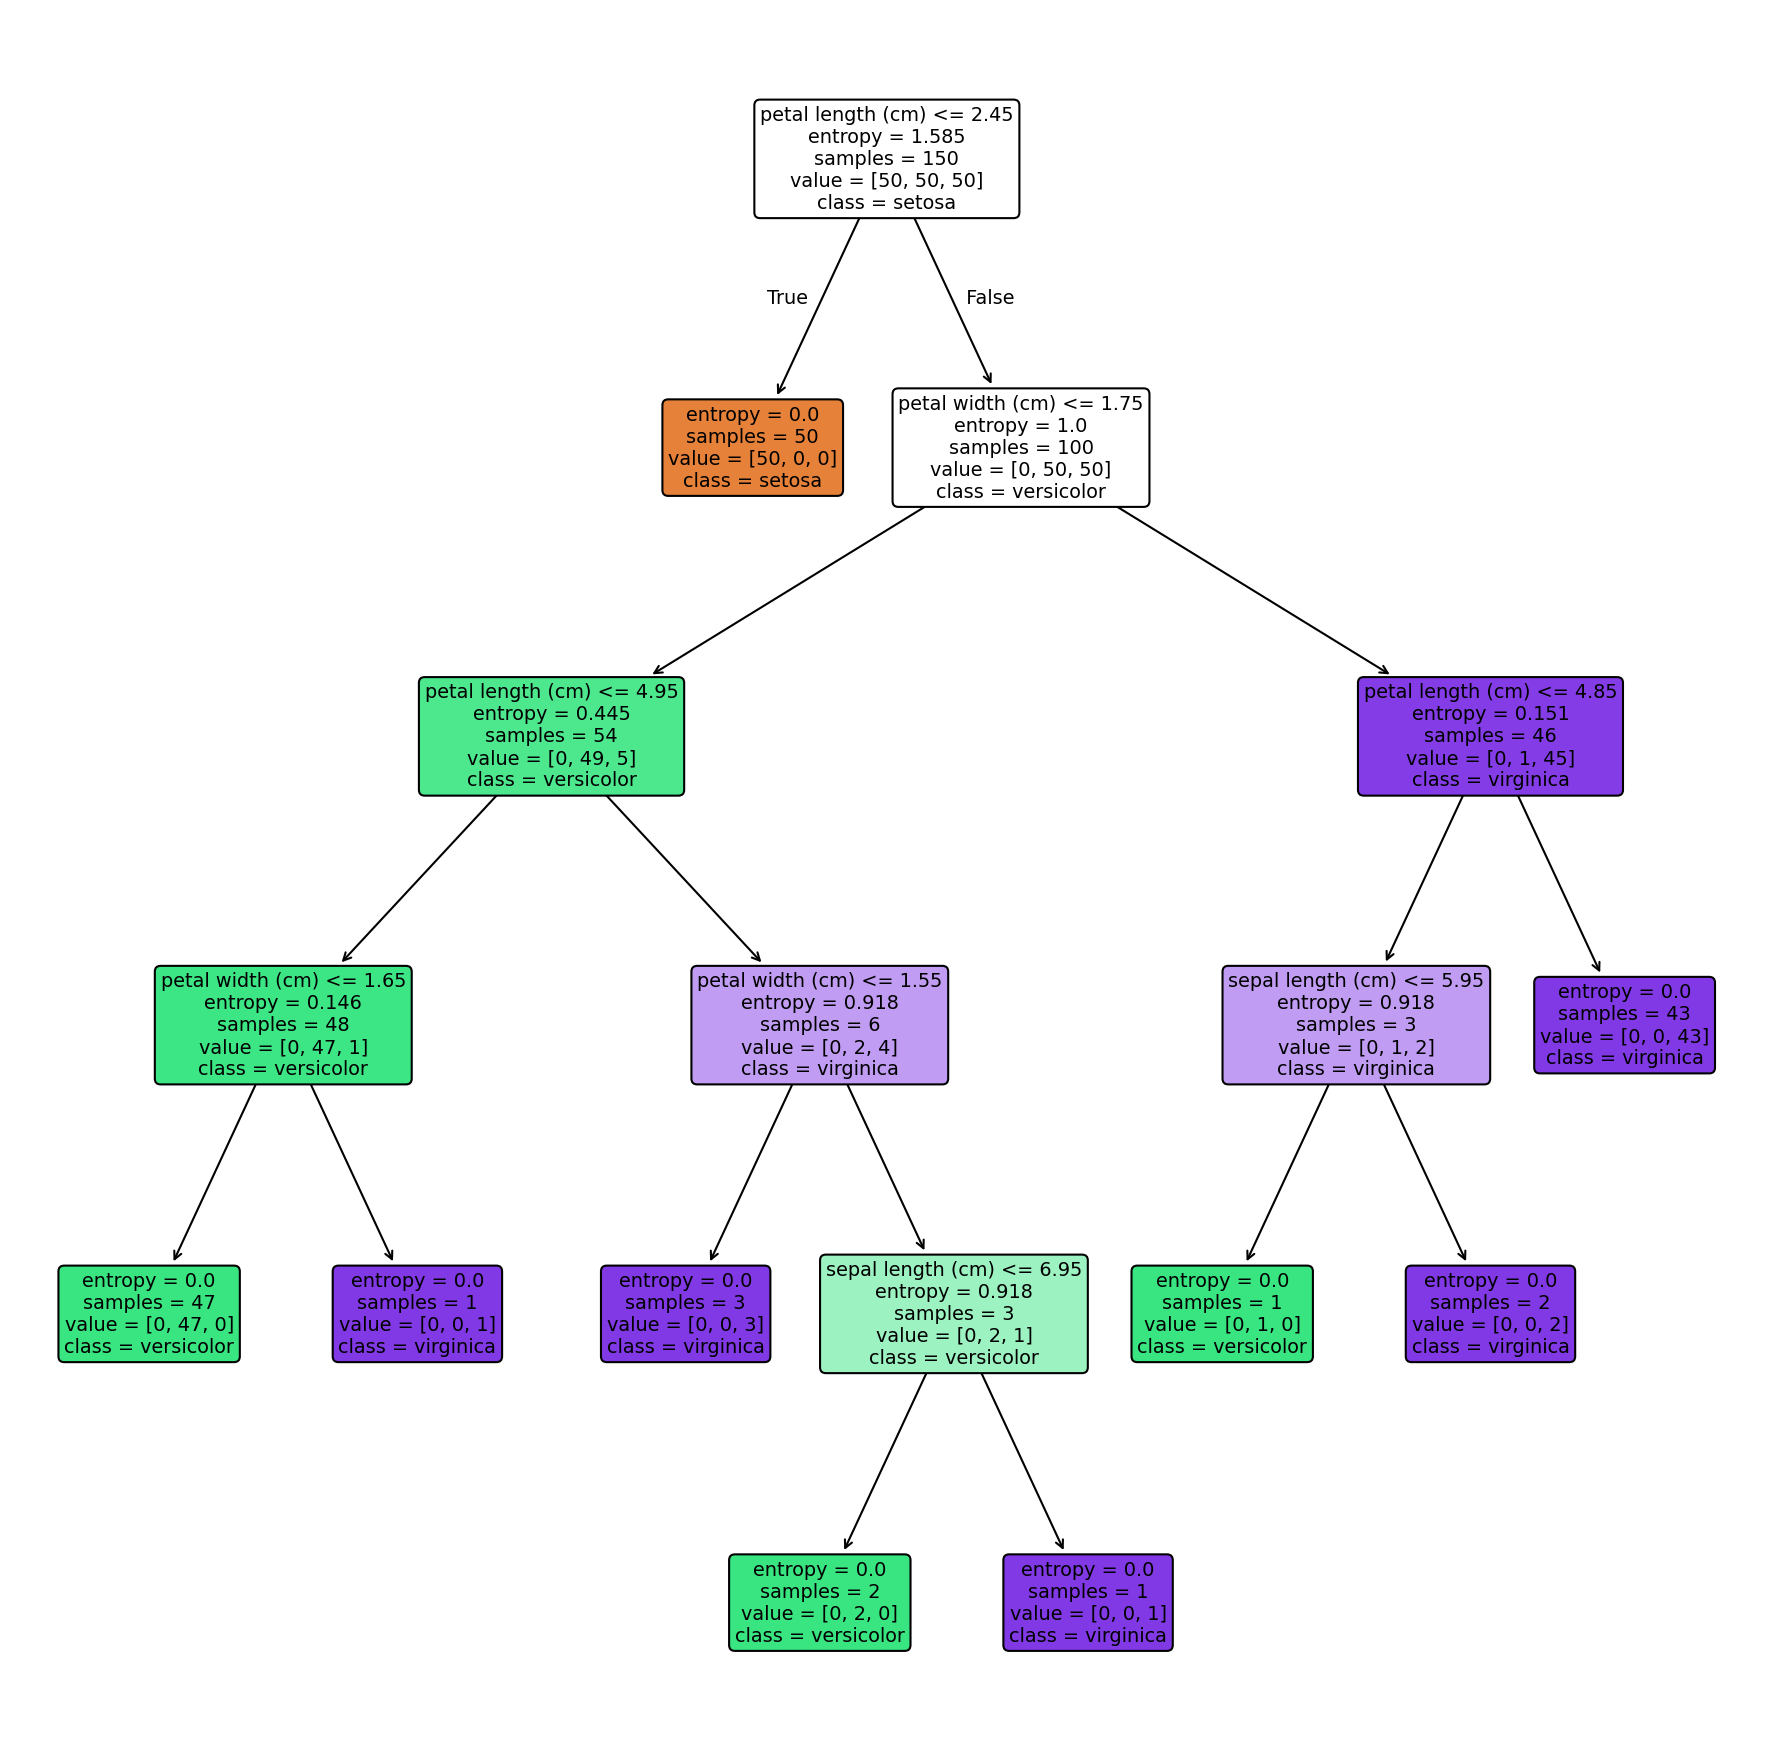

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# config size
plt.figure(figsize=(15,15), dpi=150);

# create tree visualization
plot_tree(dt_iris,
          feature_names=X_iris.columns,
          class_names=y_label,
          filled=True,
          rounded=True);
plt.show();

# left branch = True

In [25]:
y_iris.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [26]:
y_label = load_iris()['target_names']
y_label

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Model Fitting

We can use the `DecisionTreeClassifier` class from `sklearn.tree` package to create a decision tree model. The `.fit()` method takes the **training data** as arguments, which can be one array (features only) in the case of unsupervised learning, or two arrays (features and target) in the case of supervised learning.

In [27]:
# https://scikit-learn.org/stable/modules/tree.html
from sklearn.tree import DecisionTreeClassifier

# model initialization
dt_iris = DecisionTreeClassifier(criterion='entropy', random_state=123)

# training model
dt_iris.fit(X_iris, y_iris)

DecisionTreeClassifier(criterion='entropy', random_state=123)

## Tree Interpretation

We proceed to interpret the model by export the rules as text or plot the tree as `matplotlib` object:

In [28]:
from sklearn.tree import export_text
iris_rules = export_text(
    decision_tree=dt_iris,
    feature_names=X_iris.columns.to_list())
print(iris_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



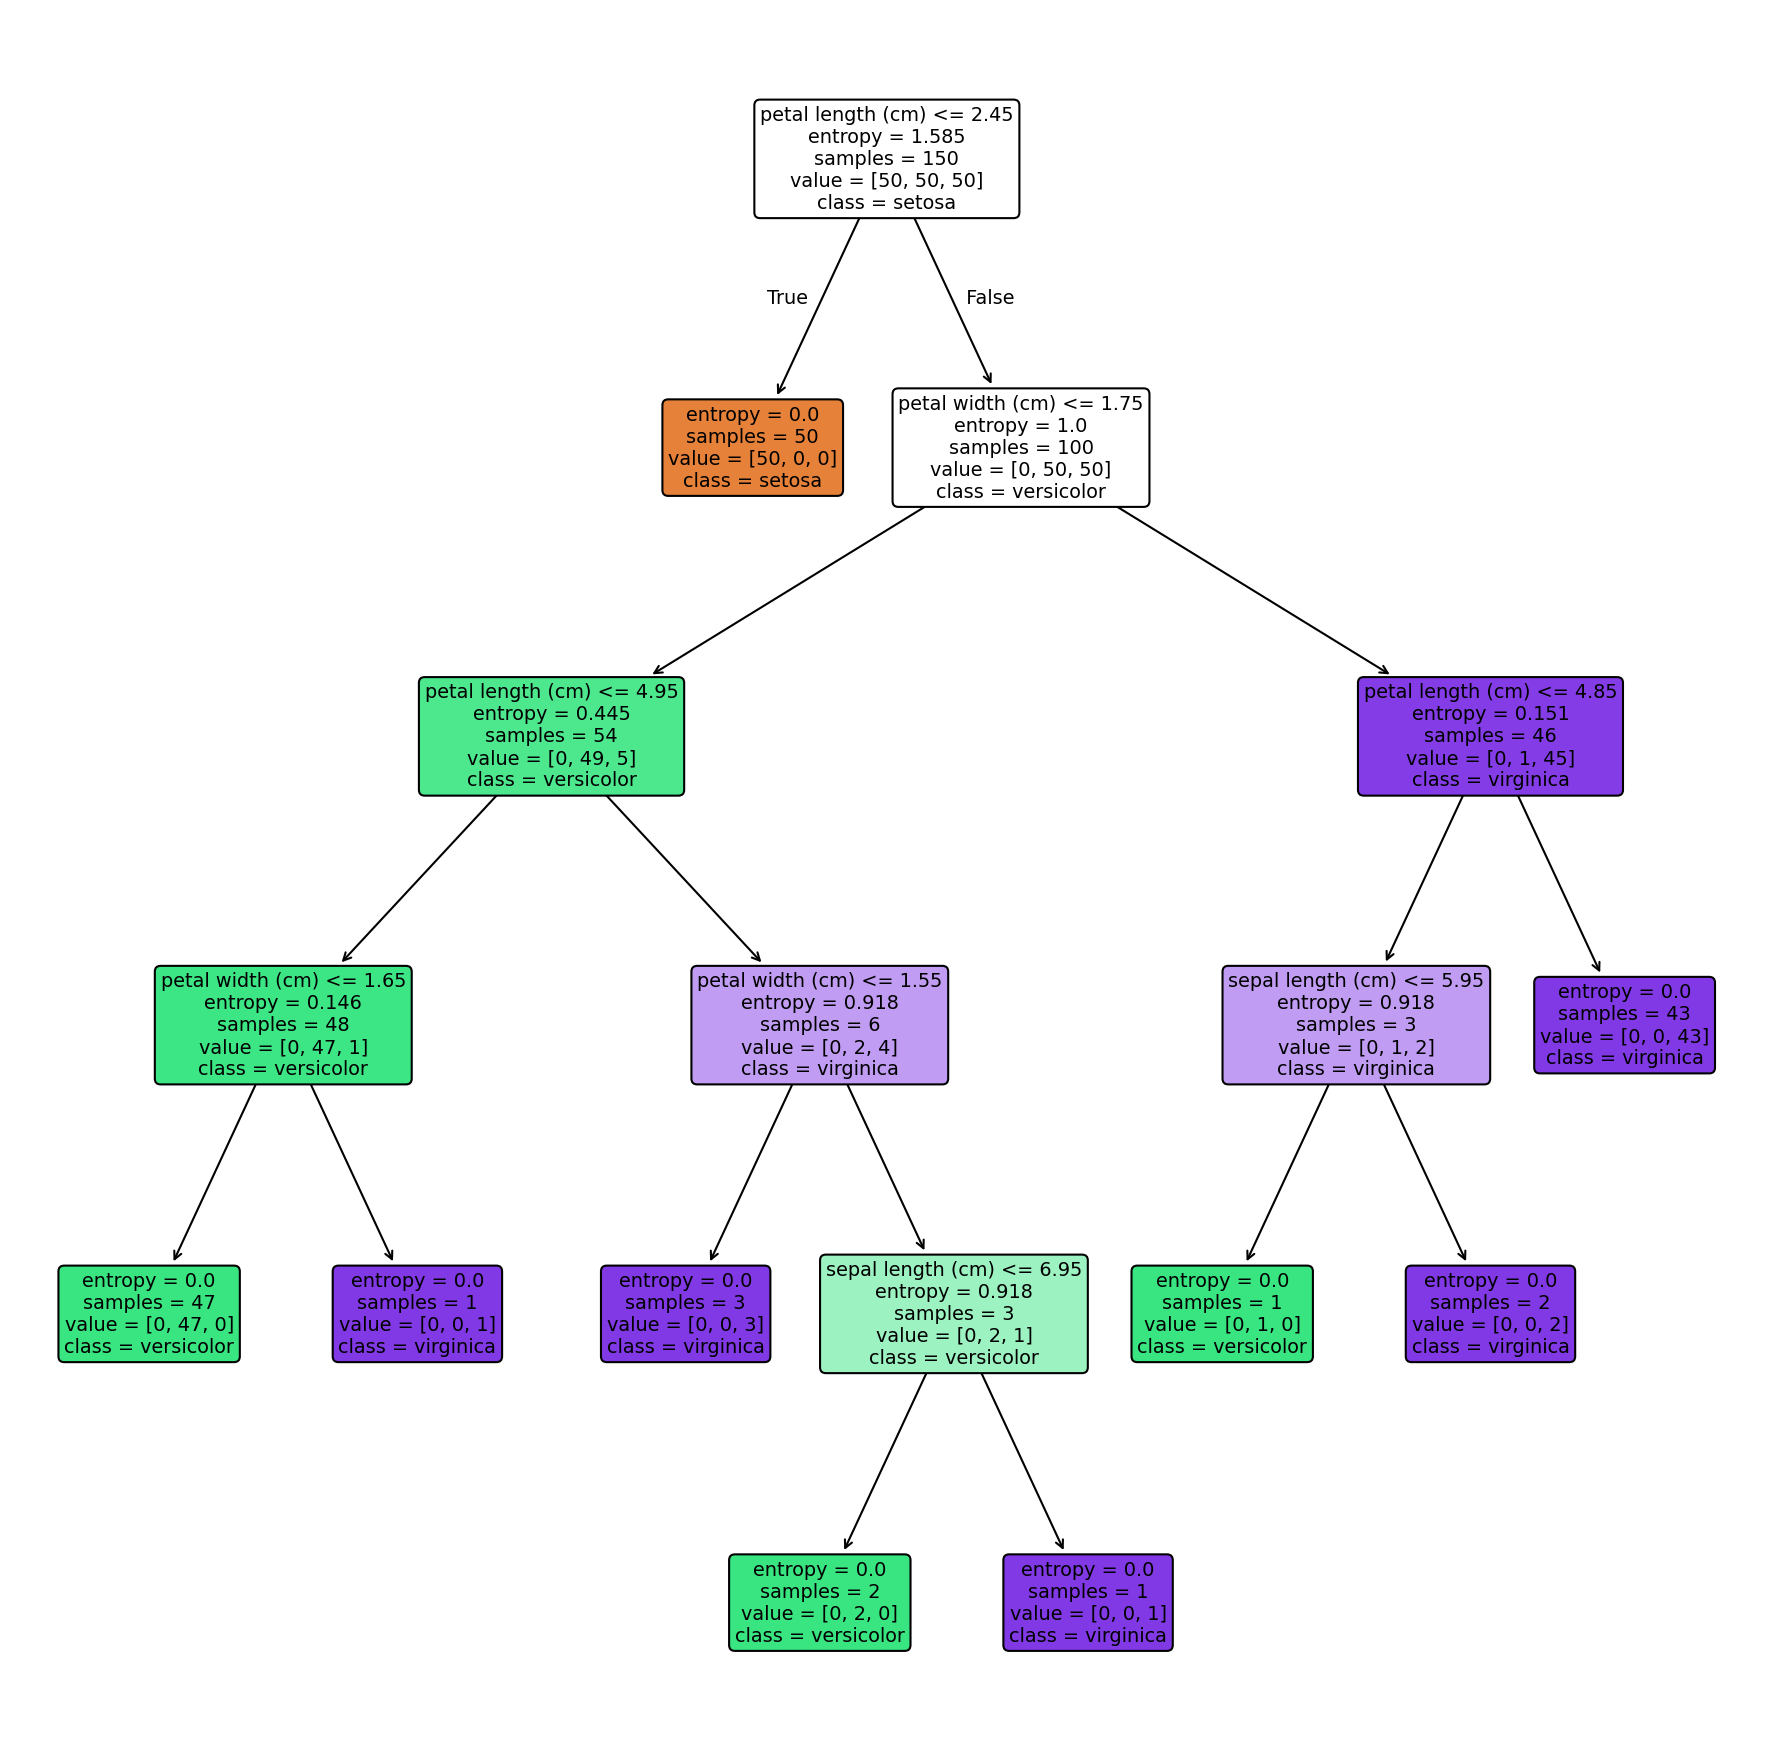

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# config size
plt.figure(figsize=(15,15), dpi=150);

# create tree visualization
plot_tree(dt_iris,
          feature_names=X_iris.columns,
          class_names=y_label,
          filled=True,
          rounded=True);
plt.show();

# left branch = True

You can also plot using `graphviz` by running `conda install -c anaconda graphviz` followed by `conda install -c anaconda python-graphviz`. Graphviz is a graph visualization tools, working with `dot` data. Visit [Graphviz Documentation Page](https://www.graphviz.org) for more information.

```
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    decision_tree=dtc_iris,
    out_file=None,
    feature_names=X_iris.columns,
    class_names=y_label,
    filled=True,
    rounded=True) 
graph = graphviz.Source(dot_data)
graph
```

If you want to export your tree into images or pdf, you can use Graphviz render:

```
graph.format = "png" # or "pdf"
graph.render("result/decision_tree")
```

Notice how our decision tree is useful because it produces rules that are are easy to interpret even for non-technical professionals. A reasonable decision tree model can be useful for field workers tasked to categorize type of flowers because they need only to remember one or two simple rules. 

How does a decision tree chooses which feature among the datasets to split on? In the earlier example, how does it pick Petal Length over Petal Width as its first splitting criterion?

Simplistically, we can imagine that the tree will choose to split the data in such a way that the resulting nodes will contain datapoints that contains as high proportion of a single class as possible. The degree to which this is possible is measured as "purity" and various decision tree implementations use a similar standard to achieve splits that ultimately increase homogeneity within the groups.

In [30]:
import pandas as pd

# split at root node
pd.crosstab(
    index=X_iris['petal length (cm)'] <= 2.45,
    columns=y_iris.apply(lambda x: y_label[x])
)

target,setosa,versicolor,virginica
petal length (cm),,,
False,0,50,50
True,50,0,0


## (Optional) Splitting Criterion: CART Algorithm

The first thing to consider in decision tree is how you split your tree. There are mainly two criterion of impurity measurement to split a tree; **Gini Index** and **Information Gain**. There's not so many differences since it's often used interchangeably.

### Gini Index

Gini index or also called gini impurity have the goals to measure how often a randomly chosen element from the set would be incorrectly labeled. 

$$
    Gini(S) = 1 - \sum^{c}_{i=1} (p_i)^2
$$

- $S$: segment of data
- $c$: number of class levels
- $p_i$: proportion of class $i$

Let's assume $c$ consists of two classes: {Positive, Negative}

**Case 1**:

In our data, the occurence of Positive is 100 and Negative is 0. Then gini result would be $1-(1+0) = 0$. The zero value of Gini impurity means the data is homogenous, and we will never incorrectly labeled Positive as Negative. 

**Case 2**:

In our data, the occurence of Positive is 50 and Negative is 50 Then gini result would be $1-(0.25+0.25) = 0.5$. This value of Gini impurity means the data is half pure.

### Information Gain

In information gain, we will use **Entropy** as a measure to split the tree. The intuition of Entropy is not so differs from Gini, but instead of using plain probability, it uses the log as well.

$$
    Entropy(S) = - \sum^{c}_{i=1} p_i\ log_{2}(p_i)
$$

- $S$: segment of data
- $c$: number of class levels
- $p_i$: proportion of class $i$

Suppose we have a segment of data with 50% Positive and 50% Negative, the entropy is:

In [31]:
import math

-0.5*math.log2(0.5) - 0.5*math.log2(0.5)

1.0

If the segment of data is 99% Positive and 1% Negative, the entropy is:

In [32]:
-0.99*math.log2(0.99) - 0.01*math.log2(0.01)

0.08079313589591118

In a binary classification case, if we have the proportion of examples in one class ($p$), we will know the proportion in the other class (1-$p$). From this we can plot the entropy for all possible values of $p$:

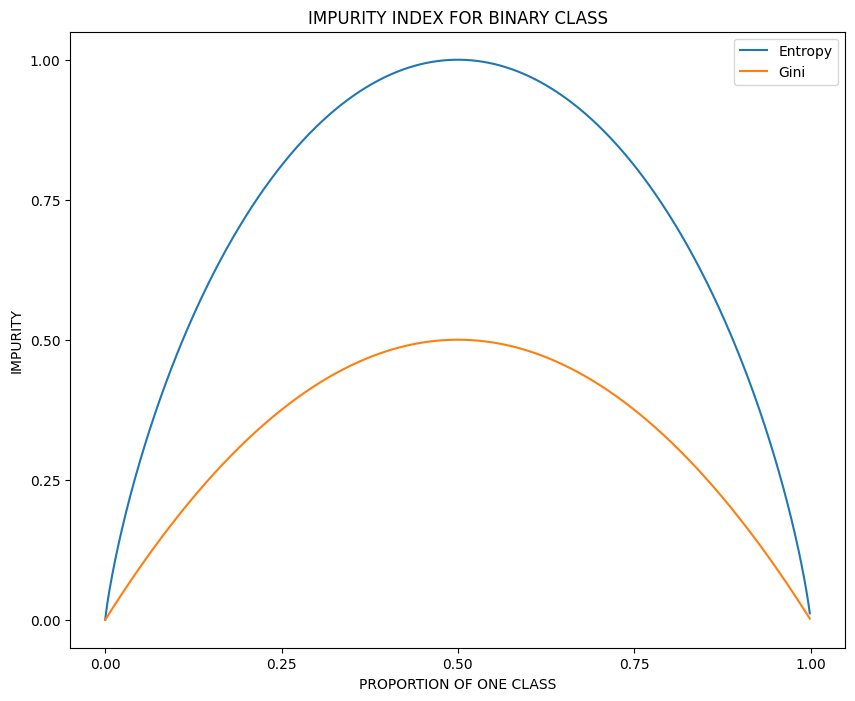

In [33]:
# FOR ILLUSTRATION PURPOSES ONLY
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8));
P = np.arange(0 + np.finfo(float).eps, 1, step=0.001)
plt.plot(P, -P*np.log2(P) - (1-P)*np.log2(1-P), label='Entropy');
plt.plot(P, 1 - P**2 - (1-P)**2, label='Gini');
plt.xticks(np.arange(0, 1.1, 0.25));
plt.yticks(np.arange(0, 1.1, 0.25));
plt.xlabel("PROPORTION OF ONE CLASS");
plt.ylabel("IMPURITY");
plt.title("IMPURITY INDEX FOR BINARY CLASS");
plt.legend();
plt.show();

So when our decision tree calculates the change in homogeneity resulting from a given split on each possible feature (known as **information gain**), it is calculating the difference between the entropy in the segment before ($S_1$) and after the split ($S_2$):

$$Information\ Gain(F)=Entropy(S_1)-Entropy(S_2)$$

Post-split, our data is divided into more than one partition so the calculation or $S_2$ has to consider the **weighted sum of entropy** across all of the partitions. In other words, the total entropy for $S_2$ is the sum of the entropy of each of the partitions weighted by their proportion of examples in that partition.

When dealing with numeric features, most decision tree classifications will test various splits by setting a numeric threshold and hence converting our numbers to a two-level categorical feature and allowing our information gain formula to work as usual.

**Notes:** As you noticed, there's not much difference from both measurement. However, Entropy can cost more computational processes compared to Gini since it uses logarithmic function. By default, `sklearn` use Gini to split the tree.

# Machine Learning Workflow: Decision Tree


In this section, we'll work on `equipment_failure.csv` dataset to predict whether the machine will failed or not (`FAILURE_TARGET`) using Decision Tree model.

## Import Data

In [34]:
import pandas as pd
equipment = pd.read_csv("data_input/equipment_failure.csv")
equipment.head()

,ID,DATE,REGION_CLUSTER,MAINTENANCE_VENDOR,MANUFACTURER,WELL_GROUP,S15,S17,S13,S5,S16,S19,S18,S8,AGE_OF_EQUIPMENT,FAILURE_TARGET
0,100001,2014-12-02,G,O,Y,1,11.088000,145.223448,39.34,3501.0,8.426869,1.9,24.610345,0.0,880,0
1,100001,2014-12-03,G,O,Y,1,8.877943,187.573214,39.20,3489.0,6.483714,1.9,24.671429,0.0,881,0
2,100001,2014-12-04,G,O,Y,1,8.676444,148.363704,38.87,3459.0,6.159659,2.0,24.733333,0.0,882,0
3,100001,2014-12-05,G,O,Y,1,9.988338,133.660000,39.47,3513.0,9.320308,2.0,24.773077,0.0,883,0
4,100001,2014-12-06,G,O,Y,1,8.475264,197.181600,40.33,3589.0,8.022960,1.5,24.808000,0.0,884,0


**Data Description:**

- `ID`: ID field that represents a specific machine.
- `DATE`: The date of the observation
- `REGION_CLUSTER`: Specific geographic or operational cluster.
- `MAINTENANCE_VENDOR`: Company or team responsible for maintenance.
- `MANUFACTURER`: Manufacturer of the equipment.
- `WELL_GROUP`: Specific group or section within the oil field.
- `S15`: Sensor 15
- `S17`: Sensor 17
- `S13`: Sensor 13
- `S5`: Sensor 5
- `S16`: Sensor 16
- `S19`: Sensor 19
- `S18`: Sensor 18
- `S8`: Sensor 8
- `AGE_OF_EQUIPMENT`: Age of the machine, in days.
- `FAILURE_TARGET`: Machine failure, 1 is failure, 0 is not failure.

We can also see the type of each columns with `info()` function. After seeing the each type of the variable, we can change the incorrect data type into the correct ones if possible.

In [35]:
equipment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307751 entries, 0 to 307750
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ID                  307751 non-null  int64  
 1   DATE                307751 non-null  object 
 2   REGION_CLUSTER      307751 non-null  object 
 3   MAINTENANCE_VENDOR  307751 non-null  object 
 4   MANUFACTURER        307751 non-null  object 
 5   WELL_GROUP          307751 non-null  int64  
 6   S15                 307751 non-null  float64
 7   S17                 307751 non-null  float64
 8   S13                 307751 non-null  float64
 9   S5                  307751 non-null  float64
 10  S16                 307751 non-null  float64
 11  S19                 307751 non-null  float64
 12  S18                 307751 non-null  float64
 13  S8                  307751 non-null  float64
 14  AGE_OF_EQUIPMENT    307751 non-null  int64  
 15  FAILURE_TARGET      307751 non-null  in

## Data Cleaning

Is there any data type that needs to be changed?

In [36]:
cat_columns = ['REGION_CLUSTER', 'MAINTENANCE_VENDOR', 'MANUFACTURER', 'WELL_GROUP']

equipment[cat_columns] = equipment[cat_columns].astype('category')

equipment.dtypes

ID                       int64
DATE                    object
REGION_CLUSTER        category
MAINTENANCE_VENDOR    category
MANUFACTURER          category
WELL_GROUP            category
S15                    float64
S17                    float64
S13                    float64
S5                     float64
S16                    float64
S19                    float64
S18                    float64
S8                     float64
AGE_OF_EQUIPMENT         int64
FAILURE_TARGET           int64
dtype: object

In [37]:
equipment = equipment.drop(columns=['ID', 'DATE'])

equipment.head()

,REGION_CLUSTER,MAINTENANCE_VENDOR,MANUFACTURER,WELL_GROUP,S15,S17,S13,S5,S16,S19,S18,S8,AGE_OF_EQUIPMENT,FAILURE_TARGET
0,G,O,Y,1,11.088000,145.223448,39.34,3501.0,8.426869,1.9,24.610345,0.0,880,0
1,G,O,Y,1,8.877943,187.573214,39.20,3489.0,6.483714,1.9,24.671429,0.0,881,0
2,G,O,Y,1,8.676444,148.363704,38.87,3459.0,6.159659,2.0,24.733333,0.0,882,0
3,G,O,Y,1,9.988338,133.660000,39.47,3513.0,9.320308,2.0,24.773077,0.0,883,0
4,G,O,Y,1,8.475264,197.181600,40.33,3589.0,8.022960,1.5,24.808000,0.0,884,0


Detecting missing values is important before doing exploratory data analysis. We will detect if the missing values is present using this function.

In [38]:
equipment.isna().sum()

REGION_CLUSTER        0
MAINTENANCE_VENDOR    0
MANUFACTURER          0
WELL_GROUP            0
S15                   0
S17                   0
S13                   0
S5                    0
S16                   0
S19                   0
S18                   0
S8                    0
AGE_OF_EQUIPMENT      0
FAILURE_TARGET        0
dtype: int64

It turns out there is no missing value in our dataframe, so we don't need to treat any missing value.

## Data Pre-processing

### Handle Numerical Data: Outlier

Handling outliers is an important stage in machine learning modelling where these outlier (extreme) values can affect model performance. Outliers are observations whose values are very far from the majority of observations and can be caused by data entry errors, anomalies, and calculation errors.

There are several techniques to prevent outliers, including:
1. Remove outliers, which removes and completely removes outliers.
2. *Scaling*, which is a technique to transform so that these outlier values will not have a major effect on the analysis results. There are various scaling techniques, such as standardisation, normalisation, min-max scaler and so on.
3. Leave the outliers as they are, if the outliers make sense in the case then no treatment should be done and continue to next section.

Let's identify the outlier values in our data using boxplots:

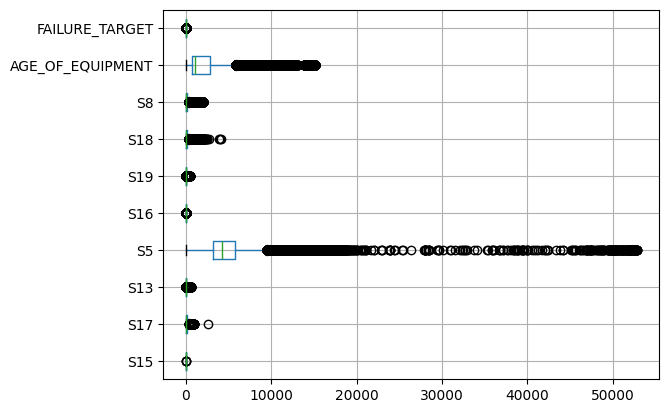

In [39]:
num_columns = equipment.select_dtypes('number').columns.to_list()

equipment.boxplot(column = num_columns, vert = False);

> **Insight:** There are many outliers in our data. Most outlier occur in `AGE_OF_EQUIPMENT` and `S5`.

In this case, we will keep outliers as they are to gaining rich and genuine information from our machine failure dataset and proceed to the next step.

### Handle Categorical Data: Encoding

In this section, we will encode our categorical features, we need to identify which type of categorical our data is so we could use appropriate encoding technique. Let's identify our categorical data wether nominal or ordinal.

In [40]:
equipment[cat_columns].head()

,REGION_CLUSTER,MAINTENANCE_VENDOR,MANUFACTURER,WELL_GROUP
0,G,O,Y,1
1,G,O,Y,1
2,G,O,Y,1
3,G,O,Y,1
4,G,O,Y,1


As we can see, all categorical columns are nominal. We will use dummy variable encoding and implement it using `.get_dummies()` as follows:

In [41]:
equip_dummy = pd.get_dummies(equipment, columns=cat_columns, drop_first=True, dtype=int)

equip_dummy.head()

,S15,S17,S13,S5,S16,S19,S18,S8,AGE_OF_EQUIPMENT,FAILURE_TARGET,...,MANUFACTURER_X,MANUFACTURER_Y,MANUFACTURER_Z,WELL_GROUP_2,WELL_GROUP_3,WELL_GROUP_4,WELL_GROUP_5,WELL_GROUP_6,WELL_GROUP_7,WELL_GROUP_8
0,11.088000,145.223448,39.34,3501.0,8.426869,1.9,24.610345,0.0,880,0,...,0,1,0,0,0,0,0,0,0,0
1,8.877943,187.573214,39.20,3489.0,6.483714,1.9,24.671429,0.0,881,0,...,0,1,0,0,0,0,0,0,0,0
2,8.676444,148.363704,38.87,3459.0,6.159659,2.0,24.733333,0.0,882,0,...,0,1,0,0,0,0,0,0,0,0
3,9.988338,133.660000,39.47,3513.0,9.320308,2.0,24.773077,0.0,883,0,...,0,1,0,0,0,0,0,0,0,0
4,8.475264,197.181600,40.33,3589.0,8.022960,1.5,24.808000,0.0,884,0,...,0,1,0,0,0,0,0,0,0,0


### Train-Test Splitting

Before we develop our classification model, I'll introduce you to the idea of estimating the performance of our model. Simply put, we are going to:

- Split our dataset into train and test sets  
- Build our machine learning model using data **only** from our train set  
- Obtain an unbiased measurement of the model's performance by predicting on test set

The idea of obtaining an unbiased estimate of our model's out-of-sample performance is an important one as it is often the case that the in-sample error (the error you obtain from running your algorithm on the dataset it was trained on) is optimistic and tuned / adapted in a particular way to minimize the error in the training sample. Therefore - the in-sample error is not a good representation or indication of how our model will perform when it is applied on unseen data.

In [42]:
# import train_test_split function dengan memanfaatkan `from`
from sklearn.model_selection import train_test_split

Before we perform train-test splitting, we need to divide the target and predictor.

- Target: `Target` column.
- Predictor: All column except `Target` and `Failure Type`.

In [43]:
# target
y = equip_dummy['FAILURE_TARGET']
# all predictor except the target
x = equip_dummy.drop(columns=['FAILURE_TARGET'])

We can use `train_test_split` with the following parameters.
- `*arrays`: the dataframe we use (split, for predictor and target variables)
- `test_size`: the percentage of the data that will be used as test data
- `train_size`: the percentage of data that will be used as test data (will be automatically filled if `test_size` is assigned a value)
- `random_state`: random number generator (RNG) value. If we enter an integer value for this parameter, it will produce the same result for the same value. If we change the value, the result will be different.

In [44]:
# split dataset into training set and test set
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=100,
                                                    stratify=y)

Let's see the proportion of the Target.

In [45]:
y_train.value_counts()

FAILURE_TARGET
0    236808
1      9392
Name: count, dtype: int64

In [46]:
y_train.value_counts(normalize=True)

FAILURE_TARGET
0    0.961852
1    0.038148
Name: proportion, dtype: float64

**Insight:**

- 0 (not Failure): 96.18%
- 1 (Failure): 3.82%

The proportions in our data train are not balanced. Balanced proportions are important so that the model can learn both positive and negative class characteristics equelly. We will encounter this problem in next section.

### Imbalance

As we already know, after splitting the train and test data, the proportions in our train data are not balanced. Balanced proportions are important so that the model can learn both positive and negative class characteristics equally (not learning from only one class). So that the prediction process will not only be good for predicting 1 class.

There are two options to make the class proportions balanced that we have learnt in previous course, **downsample** and **upsample**.

Since we have a lot of data, we will perform **downsample** using `RandomUnderSampler` from `imblearn`.

In [47]:
# import library
from imblearn.under_sampling import RandomUnderSampler

In [48]:
# Randomly remove majority class
undersampler = RandomUnderSampler(random_state=100)

# Implementation
x_train_un, y_train_un = undersampler.fit_resample(x_train, y_train)
y_train_un.value_counts()

c:\Users\arkan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\arkan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


FAILURE_TARGET
0    9392
1    9392
Name: count, dtype: int64

The result shown the target classes are balanced. It means model can learn both positive and negative class equally.

## Decision Tree

### Model Fitting

Let's us fit our training data to `DecisionTreeClassifier` with entropy splitting criterion and depth of 3.

In [49]:
from sklearn.tree import DecisionTreeClassifier

dt_equipment = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=100)
dt_equipment.fit(x_train_un, y_train_un)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=100)

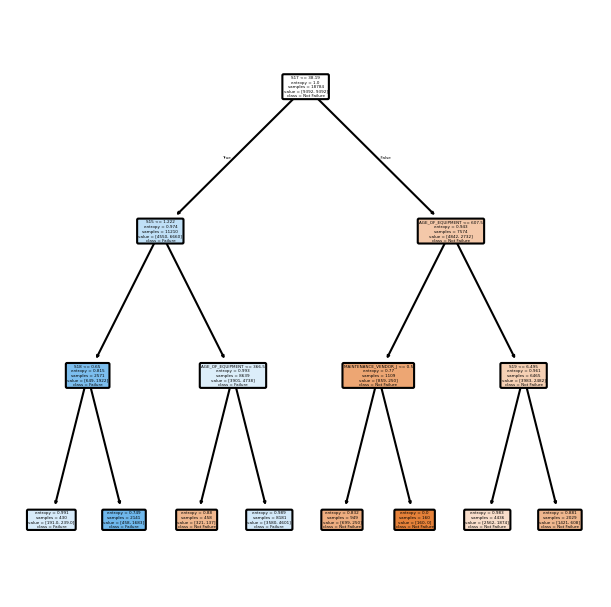

In [50]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(5,5), dpi=150);
plot_tree(dt_equipment,
          feature_names=x_train_un.columns,
          class_names=['Not Failure', 'Failure'],
          # proportion=True,
          filled=True,
          rounded=True);
plt.show();

### Model Prediction

Method `.predict()` allows us to predict the label of a new set of data, given a trained (fitted) model. This method accepts only one argument (the new data) and returns the learned label for each object in the array.

In [51]:
y_pred_dt = dt_equipment.predict(x_test)
y_pred_dt

array([0, 1, 0, ..., 0, 1, 1], dtype=int64)

For classification problems, some estimators also provide `.predict_proba()` method, which returns the **probability** that a new observation has each categorical label. In this case, the label with the highest probability is returned by `.predict()` method. For binary classification, if the predicted probability is >= 0.5, then the observation is classified as a Positive class, otherwise Negative.

Note: In decision tree model, the predicted probability is represented by the class proportion on the leaf nodes.

In [52]:
y_pred_prob_dt = dt_equipment.predict_proba(x_test)
y_pred_prob_dt[:, 1]

array([0.42245266, 0.56240068, 0.299655  , ..., 0.299655  , 0.78608127,
       0.56240068])

Additionally, we can represent the prediction result into a structured DataFrame, showing the employee ID, actual label, predicted label, and predicted probability.

In [53]:
test_result_dt = pd.DataFrame({
    'ID': x_test.index,
    'actual_label': y_test.values,
    'pred_label': y_pred_dt,
    'pred_prob': y_pred_prob_dt[:, 1]
})

test_result_dt.head()

,ID,actual_label,pred_label,pred_prob
0,297023,1,0,0.422453
1,20779,0,1,0.562401
2,69000,0,0,0.299655
3,268948,0,0,0.299655
4,69539,0,1,0.562401


### Model Evaluation (Accuracy)

All fitted estimators in `sklearn` implement a `.score()` method. This score ranges between 0 and 1, with a larger score indicating a better fit. In classification problems, it is equivalent to an accuracy score. Accuracy is the proportion of correctly identified cases from all cases. It is a common practice to compare the performance of a model on training as well as on testing data.

In [54]:
# train accuracy
dt_equipment.score(x_train_un, y_train_un)

0.6221252129471891

In [55]:
# test accuracy
dt_equipment.score(x_test, y_test)

0.5440528992217836

### Consideration on Decision Tree

Decision Trees can be **non-robust** as their model is very sensitive to the training data it is trained on: changes in training data can result in rather drastic changes to the tree.

Decision trees are also famous for being prone to **overfitting**. In `sklearn`, the hyperparameters is by default growing an overly complex tree. To make this more concrete, I'm going to implement the same decision tree algorithm but using its default:

- `max_depth=None`: Nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples.
- `min_samples_split=2`: The minimum number of samples required to split an internal node is 2.
- `min_samples_leaf=1`: The minimum number of samples required to be at a leaf node is 1.

In [56]:
dt_complex = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=100)
dt_complex.fit(x_train_un, y_train_un)

DecisionTreeClassifier(random_state=100)

By growing a complex tree model, we can easily obtain a ~100% in-sample accuracy, which is meaningless and potentially misleading:

In [57]:
# train accuracy
dt_complex.score(x_train_un, y_train_un)

1.0

In [58]:
# test accuracy
dt_complex.score(x_test, y_test)

0.8695065880326883

In [59]:
# the depth of tree after fitted into training data
dt_complex.tree_.max_depth

34

In [60]:
# overly complex tree
overfit_rules = export_text(
    decision_tree=dt_complex,
    feature_names=x_train_un.columns.to_list())
print(overfit_rules[:1000])

|--- S17 <= 38.19
|   |--- S15 <= 1.22
|   |   |--- S18 <= 0.65
|   |   |   |--- S13 <= 21.96
|   |   |   |   |--- S16 <= 1.96
|   |   |   |   |   |--- AGE_OF_EQUIPMENT <= 677.50
|   |   |   |   |   |   |--- WELL_GROUP_8 <= 0.50
|   |   |   |   |   |   |   |--- AGE_OF_EQUIPMENT <= 488.00
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- AGE_OF_EQUIPMENT >  488.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- WELL_GROUP_8 >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- AGE_OF_EQUIPMENT >  677.50
|   |   |   |   |   |   |--- S19 <= 4.40
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- S19 >  4.40
|   |   |   |   |   |   |   |--- S19 <= 8.10
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- S19 >  8.10
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- S16 >  1.96
|   |   |   |   |   |--- AGE_OF_EQUIPMENT <= 9722.50
|   |   |   |   |   |  

Another way to think about this problem is that our training data has two components to it: signal and noise. The goal of machine learning is to identify the signal but be robust enough to avoid modeling the "noise" component of the data. When we build a model, we want to know that our model is not overly adapted to the data set to the point that it captures both the signal and noise, a phenomenon known as "overfitting". When our model is guilty of overfitting, the in-sample accuracy will be very high (in some cases ~100%) but fail to perform on unseen data. The idea is to strike the **right balance** between accuracy (don't underfit) and robustness to noise (don't overfit).

![](assets/underfitting_overfitting.png)

One of many possible solution to address the overfitting problem is to make the model simpler by tuning its hyperparameters. This process of tuning is often called as **regularization**. We'll dive deep into this section later.

One other weakness in a decision tree is that all **predictor terms are by nature assumed to interact**. Intuitively, to predict a label of an observation: the predictor in the internal node have to combine with the one node above it, which in turn have to combine with the predictor even further up the tree (root node for example). This rule-based system can be too rigid for some cases of machine learning tasks.

On its own however, decision trees is quite **robust to the the problem of multicollinearity**. Imagine predictor A and predictor B both explain the effect of the target variable. A decision tree, being a greedy algorithm, will choose the one that has the highest information gain in one split, whereas a method such as logistic regression would have used both.

Finally, another important trait of decision tree is that it is **robust and insensitive to outliers**. Intuitively, imagine a measurement of height with values: 167, 170, 161, 176, 158, and 213 in cm. A decision tree's splitting criterion is going to be at a point that greedily maximizes the homogeneity within the resulting groups (the purer the better) and it is not hard to reason that, mathematically, a split at say height=168 would lead to that objective much more consistently that a split at say 200cm (thus separating only that one observation in its daughter nodes). Similarly, if there is a data entry error and you have one observation with height of 400cm, the tree's "purity objective" is still going to offset the outlier's influence.

### Modeling Improvement

In this section, we would like to address some of the problems we faced before:

- In terms of metrics selection, accuracy is a misleading metric to be used on imbalanced data. The solution is to use more representative metric.
- In terms of imbalanced data, we can apply several techniques to make sure the class proportion is somewhat balanced.
- In terms of overfitting, we can search for a sub-optimal hyperparameters to improve the model performance on train and test data.

## Model Evaluation for Classification

Previously, we only consider the training and testing accuracy using `.score()` method. Let's take a look into other evaluation metrics for classification model:

### Confusion Matrix

Confusion matrix is a special kind of frequency table, with two dimensions ("actual" and "predicted") and identical sets of target classes in both dimensions. The name stems from the fact that it makes it easy to see whether the system is confusing two classes (i.e. commonly mislabeling one as another).

In binary classification, the confusion matrix is a table with two rows and two columns that reports the number of:
- True Positive (TP): positive class being correctly classified
- True Negative (TN): negative class being correctly classified
- False Positive (FP): negative class being misclassified as positive
- False Negative (FN): positive class being misclassified as negative
    
Let's use the best model to evaluate the prediction performance, in this case, we will use `dt_complex`.

In [61]:
y_pred_dt = dt_complex.predict(x_test)
y_pred_dt

array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

In [62]:
# training confusion matrix
y_pred_train = dt_complex.predict(x_train_un)

pd.crosstab(
    index=y_pred_train,
    columns=y_train_un,
    rownames=['Predicted'],
    colnames=['Actual'],
    margins=True
)

Actual,0,1,All
Predicted,,,
0,9392,0,9392
1,0,9392,9392
All,9392,9392,18784


### Metrics

From the confusion matrix above, we can formulate these evaluation metrics to be optimized during model improvement:

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Accuracy is the proportion of correctly identified cases (TP and TN) from all cases. It is the most commonly used metrics in classification, but can be misleading (as discussed in the previous section). When predicting positives and negatives is equally important, and both classes are balanced equally, accuracy can still be useful.

$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

In [64]:
# training accuracy
accuracy_score(y_true=y_train_un, y_pred=y_pred_train)

1.0

In [65]:
# testing accuracy
accuracy_score(y_true=y_test, y_pred=y_pred_dt)

0.8695065880326883

Precision is the proportion of correctly classified positive predictions. It is also called as positive predictive value (PPV). Precision score will be higher if the False Positive is minimized.

$$Precision=\frac{TP}{TP+FP}$$

> Said another way, “for all instances classified positive, what percent was correct?”

In [66]:
# training precision
precision_score(y_true=y_train_un, y_pred=y_pred_train, pos_label=1)

1.0

In [67]:
# testing precision
precision_score(y_true=y_test, y_pred=y_pred_dt, pos_label=1)

0.21385420861860652

Recall is the proportion of positives that are correctly identified. It is also called as Sensitivity or True Positive Rate (TPR). Recall score will be higher if the False Negative is minimized.

$$Recall=\frac{TP}{TP+FN}$$

> Said another way, “for all instances that were actually positive, what percent was classified correctly?”

In [68]:
# training recall
recall_score(y_true=y_train_un, y_pred=y_pred_train, pos_label=1)

1.0

In [69]:
# testing recall
recall_score(y_true=y_test, y_pred=y_pred_dt, pos_label=1)

0.9045996592844975

F1 score is the harmonic mean of precision and recall. The harmonic mean is used instead of a simple average because it punishes extreme values. Example: a classifier with precision of 1.0 and recall of 0.0 has a simple average of 0.5 but an F1 score of 0.

$$F_1=\dfrac{2}{\frac{1}{Precision}+\frac{1}{Recall}}$$

Alternatively,

$$F_1 = \dfrac{2\times Precision\times Recall}{Precision+Recall}$$

In [70]:
# training F1 score
f1_score(y_true=y_train_un, y_pred=y_pred_train, pos_label=1)

1.0

In [71]:
# testing F1 score
f1_score(y_true=y_test, y_pred=y_pred_dt, pos_label=1)

0.34592833876221496

Instead of printing out the metrics one-by-one, we are going to use `classification_report()` provided from `sklearn.metrics` to inspect the performance of a model. Additional information:

- `support`: the number of actual occurrences of the class in the specified dataset
- `macro avg`: simple average
- `weighted avg`: weighted average based on `support`

In [72]:
# training performance
print(classification_report(
    y_true=y_train_un,
    y_pred=dt_complex.predict(x_train_un),
    target_names=['Not Failure', 'Failure'],
    digits=5))

              precision    recall  f1-score   support

 Not Failure    1.00000   1.00000   1.00000      9392
     Failure    1.00000   1.00000   1.00000      9392

    accuracy                        1.00000     18784
   macro avg    1.00000   1.00000   1.00000     18784
weighted avg    1.00000   1.00000   1.00000     18784



In [73]:
# testing performance
print(classification_report(
    y_true=y_test,
    y_pred=y_pred_dt,
    target_names=['Not Failure', 'Failure'],
    digits=5))

              precision    recall  f1-score   support

 Not Failure    0.99566   0.86811   0.92752     59203
     Failure    0.21385   0.90460   0.34593      2348

    accuracy                        0.86951     61551
   macro avg    0.60476   0.88636   0.63673     61551
weighted avg    0.96584   0.86951   0.90534     61551



**Knowledge check:**

- From the definition of Precision and Recall above, if you have to choose one of them, which metric do you think is suitable for the following cases:

    - Email spam classifier (class: Spam or Ham)
    - COVID-19 rapid test (class: Positive or Negative)
    - Customer churn prediction (class: Churn or Stay)
    - Overdue prediction of loan repayment (class: Overdue or Not Overdue)

- Compare the performance of `dt_complex` on training and testing data using confusion matrix and `classification_report()`. What can be concluded from the output?

**Answer**

> ..

## Regularization

After solving the split problem, the decision tree has one other problem to solve: it needs to know when to stop growing. If the tree grow indefinitely (and it can) it will end up splitting all data points until they are perfectly classified and yield an overly specific model (overfitting; or the case of high variance and low bias).

Regularization is a technique which makes slight modifications to the learning algorithm such that the model generalizes better. In tree-based model, the regularization often called as **pruning**.

One approach is to set a pre-determined number of levels upon which we command our tree to stop growing. This is an approach known as **pre-pruning**, but it has the obvious downside of us having to make an informed guess around the optimal depth / size of the tree.

The alternative, **post-pruning** relies on a strategy that grow the tree to too large a size and then pruning it later on once all important structures and classification patterns were discovered. Getting the best fit decision tree model means we manage to strike a good balance with our bias-variance and precision-recall tradeoffs. Reference: [Cost Complexity Pruning](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html)

Documentation of [`sklearn` `DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

> Rule-of-thumb: Increasing `min_*` or decreasing `max_*` hyperparameters will result in simpler tree model.

In [74]:
dt_reg = DecisionTreeClassifier(
    max_depth=22,
    min_samples_split=20,
    min_samples_leaf=10,
    max_leaf_nodes=None,
    random_state=100)

dt_reg.fit(x_train_un, y_train_un)

DecisionTreeClassifier(max_depth=22, min_samples_leaf=10, min_samples_split=20,
                       random_state=100)

In [75]:
# training performance
print(classification_report(
    y_true=y_train_un,
    y_pred=dt_reg.predict(x_train_un),
    target_names=['Not Failure', 'Failure'],
    digits=5))

# testing performance
print(classification_report(
    y_true=y_test,
    y_pred=dt_reg.predict(x_test),
    target_names=['Not Failure', 'Failure'],
    digits=5))

              precision    recall  f1-score   support

 Not Failure    0.90050   0.89715   0.89882      9392
     Failure    0.89753   0.90087   0.89920      9392

    accuracy                        0.89901     18784
   macro avg    0.89902   0.89901   0.89901     18784
weighted avg    0.89902   0.89901   0.89901     18784

              precision    recall  f1-score   support

 Not Failure    0.99243   0.82126   0.89877     59203
     Failure    0.15742   0.84199   0.26524      2348

    accuracy                        0.82205     61551
   macro avg    0.57492   0.83163   0.58201     61551
weighted avg    0.96057   0.82205   0.87460     61551



# Ensemble Methods

Ensemble method is a learning method that combines predictions from several machine learning models into 1 single prediction. The idea of ensembling is largely in principle and doesn't necessarily reference any particular algorithm. They describe any meta-algorithms that combine several machine learning techniques into one predictive model in order to decrease variance, reduce bias, or improve predictions.

## Wisdom of the Crowd

Wisdom of the Crowd is the collective knowledge of a group of people as expressed through their aggregated actions or opinions, regarded as an alternative to specialist or expert knowledge.

**OPTIONAL: Mathematical Point-of-View**

Suppose we create 3 different machine learning models to make a single prediction of whether a customer is classified as default or not. Obtained the following performance:

1. Logistic Regression: 70% correct
2. k-Nearest Neighbor: 70% correct
3. Decision Tree: 70% correct

In the case of classification, majority voting will be used to combine the predicted results. In this case, it means that at least 2 models are sufficient to be correct in order for them to be collectively correct.

In [76]:
# probability all three models are correct = 0.7 * 0.7 * 0.7

# probability of at least two models being correct and one model wrong
# three combinations of correct models: 1&2, 1&3, 2&3
# 3 * 0.7 * 0.7 * (1 - 0.7)

0.7 * 0.7 * 0.7 + 3 * 0.7 * 0.7 * (1 - 0.7)

0.7839999999999999

It turns out that the model performance is **collectively** better than each model. This idea underlies the concept of the ensemble method.

## Types of Ensemble Methods

### Bagging

Stands for Bootstrap Aggregating. Bootstrapping is resampling data with the same cardinality from the dataset, that could help reducing the model's variance. How bootstrapping could reduce the variance? Well, by splitting our data into several small samples and feed them into homogenous classifier, we would likely to create less-overfitted models. With less overfit means, is, a lower variance.

![](assets/bagging.jpeg)

Source: [Medium](https://medium.com/@rrfd/boosting-bagging-and-stacking-ensemble-methods-with-sklearn-and-mlens-a455c0c982de)

This method is effective if you're working with limited data, since the resample methods allows you to estimeate the score by aggregating them (the classifiers's result).

### Boosting

The main idea of boosting is to make a "teamwork" between models. Unlike Bagging where each model runs independently and then aggregated at the end, Boosting will add the models **sequentially**, one after another. A new base-learner model will be trained from the error of previous model, hence it will boost the knowledge of the whole model gradually. 

![](assets/bagging_boosting.png)

### Stacking

The previous two ensemble methods, bagging and boosting uses the same model learner. If it's decision tree, then all the learner are decision tree. Unlike both of them, stacking usually uses **different learner** to train. The other difference is stacking creates a meta-model as it's final model to predict the output. Unlike bagging where each models generates outputs, and then followed by aggregating the output (usually by average), stacking will create a **meta-model** (usually a neural network) on the last process to model the output of model learner (some people call it base learner).

![](assets/stacking.png)

# Random Forest

## Concept

Random forest is an example of bagging method. The **forest** means a bunch of decision trees (it's homogen). The **random** means there are several randomness in the model that makes this model can perform well. Two randomness of random forests are:

- Each tree is build from subsets of training sample through random sampling (with replacement)
- At each tree node, a subset of feature are randomly selected to generate the best split (rather than using all features)

In the case of classification, our forest then classify the new example through that voting mechanism while in the case of regression it simply takes the average of output.

![](assets/random_forest.png)

Among many of its advantages, random forest can be used to solve for both regression and classification tasks, handles extremely large datasets well (since the ensemble approach means it only use a small sampled subset from the full dataset), would solve for the dimensionality problems through implicit feature selection while treating noisy data (missing values and outlier values) out of the box.

## Basic Implementation

Let's us fit our training data to `RandomForestClassifier` with default parameters. By default it uses 100 trees.

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_equipment = RandomForestClassifier(random_state=100, oob_score=True)
rf_equipment.fit(x_train_un, y_train_un)

RandomForestClassifier(oob_score=True, random_state=100)

In [78]:
# pickle.dump(rf_equipment, open("model/rf_equipment.pkl", "wb"))

In [81]:
# loading model
# rf_equipment = pickle.load(open('model/rf_equipment.pkl','rb'))

### Out-of-Bag Score

In practice, the random forest already have out-of-bag estimates (OOB) that can be used as a reliable estimate of its true accuracy on unseen examples. Specifically, for each tree that our random forest constructs, any example not selected to train the decision model is used to test the tree’s performance on unseen data. Then, for each observation in our dataset, our random forest count the votes to determine the final predicted class. This total error rate is the out-of-bag error rate.

In [82]:
rf_equipment.oob_score_

0.9353172913117547

We can also print out the computed out-of-bag decision function on the training set. If `n_estimators` is small it might be possible that a data point was never left out during the bootstrap. In this case, `oob_decision_function_` might contain `NaN`.

In [83]:
rf_equipment.oob_decision_function_

array([[0.92682927, 0.07317073],
       [0.96774194, 0.03225806],
       [0.28571429, 0.71428571],
       ...,
       [0.125     , 0.875     ],
       [0.10810811, 0.89189189],
       [0.32352941, 0.67647059]])

Note that both `oob_score_` and `oob_decision_function_` exists only when `oob_score` is `True`.

Now, let's check perfomance in data train:

In [84]:
# training performance
print(classification_report(
    y_true=y_train_un,
    y_pred=rf_equipment.predict(x_train_un),
    target_names=['Not Failure', 'Failure'],
    digits=5))

              precision    recall  f1-score   support

 Not Failure    1.00000   1.00000   1.00000      9392
     Failure    1.00000   1.00000   1.00000      9392

    accuracy                        1.00000     18784
   macro avg    1.00000   1.00000   1.00000     18784
weighted avg    1.00000   1.00000   1.00000     18784



From the results of the evaluation above, we can see that the value for all evaluation metrics is nearly perfect. This result should be suspicious considering that machine learning model is unlikely to produce errors. Now, let's check preformance in data test:

In [85]:
# testing performance
print(classification_report(
    y_true=y_test,
    y_pred=rf_equipment.predict(x_test),
    target_names=['Not Failure', 'Failure'],
    digits=5))

              precision    recall  f1-score   support

 Not Failure    0.99848   0.91935   0.95728     59203
     Failure    0.32173   0.96465   0.48253      2348

    accuracy                        0.92107     61551
   macro avg    0.66011   0.94200   0.71990     61551
weighted avg    0.97266   0.92107   0.93917     61551



As we assumed before, results evaluation of model in test data is significantly different for recall value in the positive class. This means that the overfit estimation in `model_rf_ori` is correct. 

In [86]:
from sklearn.model_selection import cross_val_score

rf_no_oob = RandomForestClassifier(random_state=100) # will run faster than oob_score=True
cross_val_score(rf_no_oob, x_train_un, y_train_un, cv=3, scoring='recall')

array([0.94857873, 0.9571885 , 0.95975727])

### Feature Importances

We can inspect `feature_importances_` attribute from the fitted random forest to get a list of the most important variables used in the model. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature across `n_estimators` trees. It is also known as the Gini importance.

Warning: impurity-based feature importances can be misleading for high cardinality features (many unique values). See `sklearn.inspection.permutation_importance` as an alternative.

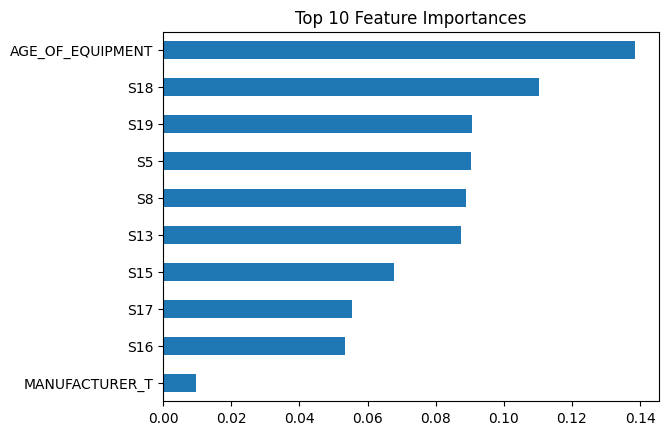

In [87]:
pd.Series(
    rf_equipment.feature_importances_,
    index=x_train_un.columns
    ).sort_values().tail(10).plot.barh(title="Top 10 Feature Importances");

From the plot above, top three features based on their importance are:

1. `AGE_OF_EQUIPMENT`
2. `S18`
3. `S19`

# Reference

1. Müller Andreas C., &amp; Guido, S. (2018). Introduction to machine learning with python: A guide for data scientists. O'Reilly Media, Inc. 
2. Master Machine Learning Algorithms: Discover How They Work and Implement Them From Scratch. 2016. Jason Brownlee. Machine Learning Mastery, http://machinelearningmastery.com/
3. Materials for scikit-learn Tutorial. 2019. Jake Vanderplas. https://github.com/jakevdp/sklearn_tutorial/, BSD-3-Clause license, Google (Oakland CA)
